# Dataset B – Wine Quality


In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import StratifiedKFold, learning_curve, cross_validate
from sklearn.metrics import confusion_matrix

SEED = 49
np.random.seed(SEED)
random.seed(SEED)

### Data Loading

We load the Wine Quality dataset and inspect its basic structure.

In [3]:
DATA_PATH = "../wine.csv"
df = pd.read_csv(DATA_PATH)

df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,class,type,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,5


The variables quality, class, and type are categorical in nature, despite being encoded as integers. Specifically, quality is an ordinal multi-class target variable, type is a binary categorical feature, and class represents a discrete categorical grouping. All remaining features are continuous numerical physicochemical measurements.

### Target Variable Distribution

We analyze class balance to motivate metric selection.

In [4]:
target_col = "quality"
df[target_col].value_counts()

4    2251
5    1561
3    1467
6     813
7     204
2     163
1      20
8      18
Name: quality, dtype: int64

In [5]:
df[target_col].value_counts(normalize=True)

4    0.346468
5    0.240265
3    0.225797
6    0.125135
7    0.031399
2    0.025089
1    0.003078
8    0.002771
Name: quality, dtype: float64

Because the Wine dataset is unbalanced, accuracy may overestimate performance in the majority classes. Therefore, we adopt Macro-F1 as the primary evaluation metric.

## Experiments

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

X = df.drop(columns=["quality", "class"])
y = df["quality"]

num_cols = ["fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar", 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'pH', 'density', 'sulphates', 'alcohol']
cat_cols = ["type"]

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)


In [7]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.20
VAL_SIZE  = 0.10

y_arr = pd.Series(y).values

X_train_t, X_test, y_train_t, y_test = train_test_split(
    X, y_arr, test_size=TEST_SIZE, stratify=y_arr, random_state=SEED
)

val_size_within_train = VAL_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_t, y_train_t, test_size=val_size_within_train, stratify=y_train_t, random_state=SEED
)

### Neural Network

#### PyTorch + SVD

In [8]:
import torch

X_train_sp = preprocessor.fit_transform(X_train)
X_val_sp   = preprocessor.transform(X_val)
X_test_sp  = preprocessor.transform(X_test)

X_train_nn = X_train_sp.toarray() if hasattr(X_train_sp, "toarray") else np.asarray(X_train_sp)
X_val_nn   = X_val_sp.toarray()   if hasattr(X_val_sp, "toarray")   else np.asarray(X_val_sp)
X_test_nn  = X_test_sp.toarray()  if hasattr(X_test_sp, "toarray")  else np.asarray(X_test_sp)

X_train_nn = X_train_nn.astype(np.float32, copy=False)
X_val_nn   = X_val_nn.astype(np.float32, copy=False)
X_test_nn  = X_test_nn.astype(np.float32, copy=False)

y_train_s = np.asarray(y_train)
y_val_s   = np.asarray(y_val)
y_test_s  = np.asarray(y_test)

classes = np.unique(np.concatenate([y_train_s, y_val_s, y_test_s]))
class_to_idx = {c: i for i, c in enumerate(classes)}

y_train_idx = np.vectorize(class_to_idx.get)(y_train_s).astype(np.int64)
y_val_idx   = np.vectorize(class_to_idx.get)(y_val_s).astype(np.int64)
y_test_idx  = np.vectorize(class_to_idx.get)(y_test_s).astype(np.int64)

X_train_nn_t = torch.from_numpy(X_train_nn)
X_val_nn_t   = torch.from_numpy(X_val_nn)
X_test_nn_t  = torch.from_numpy(X_test_nn)

y_train_nn = torch.tensor(y_train_idx, dtype=torch.long)
y_val_nn   = torch.tensor(y_val_idx,   dtype=torch.long)
y_test_nn  = torch.tensor(y_test_idx,  dtype=torch.long)

input_dim = X_train_nn_t.shape[1]
num_classes = len(classes)

In [9]:
import torch
import torch.nn as nn

class MLP_tmp(nn.Module):
    """
    MLP for multiclass classification
    """
    def __init__(self, d, h, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Linear(d, h),
            nn.ReLU()
        )
        self.classifier = nn.Linear(h, num_classes)

    def forward(self, x):
        """
        Perform a forward pass through the network

        Input:
            x (torch.Tensor): input batch 

        Return:
            torch.Tensor: raw logits 
        """
        return self.classifier(self.features(x))

    def freeze_all(self):
        """
        Freeze all model parameters

        Input: None

        Return: None
        """
        for p in self.parameters():
            p.requires_grad = False

    def unfreeze_last_k(self, k=1):
        """
        Unfreeze the last k logical layers of the network
        
        Input:
            k (int): number of layers from the output backward to unfreeze

        Return: None
        """
        self.freeze_all()
        for p in self.classifier.parameters():
            p.requires_grad = True
        if k >= 2:
            for m in self.features:
                if isinstance(m, nn.Linear):
                    for p in m.parameters():
                        p.requires_grad = True
                        
    def count_trainable_params(self):
        """
        Count the number of trainable parameters

        Input: None

        Return:
            int: number of parameters with requires_grad = True
        """
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [10]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score
import gc
import time


gc.collect()
torch.manual_seed(SEED)
np.random.seed(SEED)


BATCH_SIZE = 64

train_ds = TensorDataset(X_train_nn_t, y_train_nn)
val_ds   = TensorDataset(X_val_nn_t,   y_val_nn)
test_ds  = TensorDataset(X_test_nn_t,  y_test_nn)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = MLP_tmp(d=input_dim, h=32, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def eval_f1(model, loader):
    """
    Compute Macro-F1 score for a PyTorch model

    Input:
        model (torch.nn.Module): trained neural network model
        loader (DataLoader): DataLoader providing evaluation batches
    Return:float: Macro-F1 score computed on the provided dataset
    """
    preds, ys = [], []

    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(torch.argmax(model(xb), dim=1).cpu().numpy())
            ys.append(yb.cpu().numpy())

    return f1_score(np.concatenate(ys), np.concatenate(preds), average="macro")


def eval_loss(model, loader):
    """
    Compute average loss

    Input:
        model (torch.nn.Module): trained neural network model
        loader (DataLoader): DataLoader providing evaluation batches

    Return:
        float: average loss computed across all samples in the dataset
    """
    total, n = 0.0, 0
    model.eval()
    
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb), yb)
            bs = yb.size(0)
            total += loss.item() * bs
            n += bs
    return total / n


grad_evals = 0
t0 = time.time()

for epoch in range(10):  
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        grad_evals += 1
    vloss = eval_loss(model, val_loader)
    vf1   = eval_f1(model, val_loader)
    print(f"epoch {epoch:02d} | val_loss={vloss:.4f} | val_f1={vf1:.4f} | grad_evals={grad_evals} | time={time.time()-t0:.1f}s")


2026-03-03 22:13:47.239032: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


epoch 00 | val_loss=1.5660 | val_f1=0.2216 | grad_evals=72 | time=0.3s
epoch 01 | val_loss=1.2895 | val_f1=0.2575 | grad_evals=144 | time=0.4s
epoch 02 | val_loss=1.2001 | val_f1=0.2653 | grad_evals=216 | time=0.6s
epoch 03 | val_loss=1.1518 | val_f1=0.2794 | grad_evals=288 | time=0.7s
epoch 04 | val_loss=1.1240 | val_f1=0.2708 | grad_evals=360 | time=0.9s
epoch 05 | val_loss=1.1028 | val_f1=0.2973 | grad_evals=432 | time=1.1s
epoch 06 | val_loss=1.0876 | val_f1=0.3116 | grad_evals=504 | time=1.3s
epoch 07 | val_loss=1.0773 | val_f1=0.3256 | grad_evals=576 | time=1.4s
epoch 08 | val_loss=1.0663 | val_f1=0.3368 | grad_evals=648 | time=1.6s
epoch 09 | val_loss=1.0608 | val_f1=0.3275 | grad_evals=720 | time=1.7s


In [11]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

@torch.no_grad()
def evaluate_multiclass(model, loader, device="cpu", average="macro"):
    """
    Evaluate a multiclass classification model

    Input:
        model (torch.nn.Module): trained neural network model
        loader (DataLoader): DataLoader providing evaluation batches
        device (str or torch.device): device on which the model is evaluated
        average (str): averaging mode for multiclass F1

    Return:
        dict: dictionary containing the accuracy, F1 score with the specified averaging mode, confusion matrix and predicted class labels
    """
    model.eval()
    preds, ys = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        preds.append(torch.argmax(logits, dim=1).cpu().numpy())
        ys.append(yb.cpu().numpy())
    y_pred = np.concatenate(preds)
    y_true = np.concatenate(ys)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average=average),
        "cm": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred
    }

In [12]:
res = evaluate_multiclass(model, val_loader, device=device, average="macro")
print("Accuracy:", res["accuracy"])
print("Macro-F1:", res["f1"])
print("Confusion matrix:\n", res["cm"])

Accuracy: 0.5661538461538461
Macro-F1: 0.3275220517403244
Confusion matrix:
 [[  0   0   0   2   0   0   0   0]
 [  0   0  11   5   0   0   0   0]
 [  0   0  79  63   5   0   0   0]
 [  0   0  39 167  19   0   0   0]
 [  0   0   4  56  67  29   0   0]
 [  0   0   0   9  21  50   1   0]
 [  0   0   0   0   0  16   5   0]
 [  0   0   0   0   0   1   1   0]]


In [13]:
from sklearn.metrics import classification_report, f1_score

y_true_val = y_val_nn.numpy() if hasattr(y_val_nn, "numpy") else y_val_nn
print("\n[VAL] Classification report:\n", classification_report(y_true_val, res["y_pred"]))


[VAL] Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00        16
           2       0.59      0.54      0.56       147
           3       0.55      0.74      0.63       225
           4       0.60      0.43      0.50       156
           5       0.52      0.62      0.56        81
           6       0.71      0.24      0.36        21
           7       0.00      0.00      0.00         2

    accuracy                           0.57       650
   macro avg       0.37      0.32      0.33       650
weighted avg       0.56      0.57      0.55       650



/Users/juancarloshenriquez/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/juancarloshenriquez/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/juancarloshenriquez/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start,

In [14]:
import copy
baseline_state = copy.deepcopy(model.state_dict())

## PART 1

### Hypothesis

Because the last layers of a trained backbone are closer to a near-convex classification head, we expect randomized optimization (RO) over only the last layers to sometimes find slightly better “tail” validation loss than local gradient updates restricted to the same layers. However, under strict function-evaluation budgets, RO should be less sample-efficient and show higher variance across seeds. For Wine (multiclass), we expect GA to be the most robust due to population diversity, while RHC may plateau early.

In [15]:
def count_trainable_params(m):
    """
    Count the number of trainable parameters in a model
    
    Input:
        m (torch.nn.Module): neural network model

    Return:
        int: total number of trainable parameters
    """
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

PARAM_CAP = 50_000

def prepare_last_k(m, k):
    """
    Reset a model to baseline weights and unfreeze the last k layers
    
    Input:
        m (torch.nn.Module): model to reset and modify
        k (int): number of last layers to unfreeze

    Return:
        int: number of trainable parameters after unfreezing last k layers
    """
    m.load_state_dict(baseline_state)
    m.unfreeze_last_k(k=k)
    return count_trainable_params(m)

for k in [1, 2]:
    tp = prepare_last_k(model, k)
    print(f"k={k} -> trainable params = {tp}")

chosen_k = None
for k in [2, 1]:
    tp = prepare_last_k(model, k)
    if tp <= PARAM_CAP:
        chosen_k = k
        chosen_tp = tp
        break

print(f"Chosen k={chosen_k} with trainable params={chosen_tp} (cap={PARAM_CAP})")

k=1 -> trainable params = 264
k=2 -> trainable params = 712
Chosen k=2 with trainable params=712 (cap=50000)


In [16]:
def get_trainable_tensors(m):
    """
    Retrieve all trainable parameter tensors from a model

    Input:
        model (torch.nn.Module): neural network model

    Return:
        list[torch.Tensor]: list of parameters with requires_grad = True
    """
    return [p for p in m.parameters() if p.requires_grad]

def flatten_trainable(m):
    """
    Flatten all trainable parameters into a single 1D vector

    Input:
        model (torch.nn.Module): neural network model

    Return:
        torch.Tensor: flattened 1D vector of all trainable parameters
    """
    vec = torch.cat([p.detach().flatten() for p in get_trainable_tensors(m)], dim=0)
    return vec.to(device)

@torch.no_grad()
def assign_flattened_trainable(m, flat_vec):
    """
    Assign a flattened parameter vector back to the model's trainable parameters
    
    Input:
        model (torch.nn.Module): neural network model
        flat_vec (torch.Tensor): flattened parameter vector

    Return: None
    """
    flat_vec = flat_vec.detach().to(device)
    offset = 0
    for p in get_trainable_tensors(m):
        n = p.numel()
        p.copy_(flat_vec[offset:offset+n].view_as(p))
        offset += n
    assert offset == flat_vec.numel()

class ROObjective:
    """
    Objective wrapper for Randomized Optimization
    """
    def __init__(self, m, loader):
        self.m = m
        self.loader = loader
        self.fevals = 0

    def __call__(self, flat_vec):
        """
        Evaluate validation loss for a given parameter vector

        Input:
            flat_vector (torch.Tensor): flattened parameter vector

        Return:
            float: validation loss value
        """
        self.fevals += 1
        assign_flattened_trainable(self.m, flat_vec)
        return float(eval_loss(self.m, self.loader))


In [17]:
model.load_state_dict(baseline_state)
model.unfreeze_last_k(k=chosen_k)

x0 = flatten_trainable(model)
obj = ROObjective(model, val_loader)

y0 = obj(x0)
print("RO dim:", x0.numel())
print("Initial val loss:", y0, "| fevals:", obj.fevals)

RO dim: 712
Initial val loss: 1.0607830201662505 | fevals: 1


### RHC

In [19]:
import math
import time

def set_all_seeds(seed: int):
    """
    Set random seeds for full reproducibility
    
    Input:
        seed (int): random seed value
    
    Return: None
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def rhc(obj, x_init, max_fevals=8000, restarts=10, sigma_init=0.02, sigma_decay=0.999, seed=49):
    """
    RHC with restarts and step-size decay
    
    Input:
        obj (callable): objective function returning validation loss
        x_init (torch.Tensor): initial solution vector
        max_fevals (int): maximum number of function evaluations allowed
        restarts (int): number of restart attempts
        sigma_init (float): initial Gaussian perturbation scale
        sigma_decay (float): multiplicative decay applied to sigma each step
        seed (int): random seed for reproducibility

    Return:
        best_x (torch.Tensor): best solution found
        best_y (float): best objective value (validation loss)
        hist (pd.DataFrame): history containing function evaluation count, best-so-far validation loss, elapsed time in seconds
    """
    set_all_seeds(seed)
    start = time.time()

    best_x = x_init.clone()
    best_y = obj(best_x)

    sigma = sigma_init
    history = [(obj.fevals, best_y, time.time() - start)]

    fevals_per_restart = max(1, max_fevals // max(1, restarts))

    for r in range(restarts):

        x = best_x.clone()
        y = best_y

        while obj.fevals < (r + 1) * fevals_per_restart and obj.fevals < max_fevals:
            x_prop = x + torch.randn_like(x) * sigma
            y_prop = obj(x_prop)

            if y_prop < y:
                x, y = x_prop, y_prop
                if y < best_y:
                    best_x, best_y = x.clone(), y

            sigma *= sigma_decay
            history.append((obj.fevals, best_y, time.time() - start))

    hist = pd.DataFrame(history,
                        columns=["fevals", "best_val_loss", "time_s"])

    return best_x, best_y, hist

### SA

In [20]:
def sa(obj, x_init, max_fevals=8000, T0=1.0, alpha=0.999, sigma_init=0.02, sigma_decay=0.9995, seed=49):
    """
    SA with exponential temperature cooling and Gaussian perturbations

    Input:
        obj (callable): objective function returning validation loss
        x_init (torch.Tensor): initial solution vector
        max_fevals (int): maximum number of function evaluations allowed
        T0 (float): initial temperature
        alpha (float): multiplicative temperature decay factor 
        sigma_init (float): initial Gaussian perturbation scale
        sigma_decay (float): multiplicative decay for perturbation scale
        seed (int): random seed for reproducibility

    Return:
        best_x (torch.Tensor): best solution found
        best_y (float): best objective value (validation loss)
        hist (pd.DataFrame): history containing function evaluation count, best-so-far validation loss, elapsed time in seconds
    """
    set_all_seeds(seed)
    start = time.time()

    x = x_init.clone()
    y = obj(x)

    best_x, best_y = x.clone(), y
    T = T0
    sigma = sigma_init

    history = [(obj.fevals, best_y, time.time() - start)]

    while obj.fevals < max_fevals:
        x_prop = x + torch.randn_like(x) * sigma
        y_prop = obj(x_prop)

        if y_prop < y:
            accept = True
        else:
            accept_prob = math.exp(-(y_prop - y) / max(1e-12, T))
            accept = (random.random() < accept_prob)

        if accept:
            x, y = x_prop, y_prop
            if y < best_y:
                best_x, best_y = x.clone(), y

        T *= alpha
        sigma *= sigma_decay
        history.append((obj.fevals, best_y, time.time() - start))

    hist = pd.DataFrame(history, columns=["fevals", "best_val_loss", "time_s"])
    return best_x, best_y, hist


### GA

In [21]:
def ga(obj, x_init, max_fevals = 8000, pop_size = 40, elite_frac = 0.10, tournament_k = 3, crossover_rate = 0.6, mutation_rate = 0.2, mutation_sigma = 0.02, seed = 49):
    """
    GA with elitism, tournament selection, uniform crossover and Gaussian mutation

    Input:
        obj (callable): objective function returning validation loss
        x_init (torch.Tensor): initial solution vector
        max_fevals (int): maximum number of function evaluations allowed
        pop_size (int): population size
        elite_frac (float): fraction of top individuals preserved each generation
        tournament_k (int): tournament size for parent selection
        crossover_rate (float): probability of applying crossover
        mutation_rate (float): probability of mutating each offspring
        mutation_sigma (float): standard deviation of Gaussian mutation
        seed (int): random seed for reproducibility

    Return:
        best_x (torch.Tensor): best solution found
        best_y (float): best objective value (validation loss)
        hist (pd.DataFrame): history containing function evaluation count, best-so-far validation loss, elapsed time in seconds
    """
    set_all_seeds(seed)

    start = time.time()
    dim = x_init.numel()
    elite_n = max(1, int(pop_size * elite_frac))

    pop = [x_init + torch.randn_like(x_init) * mutation_sigma
           for _ in range(pop_size)]
    pop_scores = [obj(x) for x in pop]

    best_idx = int(np.argmin(pop_scores))
    best_x = pop[best_idx].clone()
    best_y = float(pop_scores[best_idx])

    history = [(obj.fevals, best_y, time.time() - start)]

    while obj.fevals < max_fevals:

        elite_idxs = np.argsort(pop_scores)[:elite_n]
        new_pop = [pop[i].clone() for i in elite_idxs]

        while len(new_pop) < pop_size and obj.fevals < max_fevals:
            idxs = np.random.choice(pop_size, size=tournament_k, replace=False)
            best_i = idxs[0]
            for i in idxs[1:]:
                if pop_scores[i] < pop_scores[best_i]:
                    best_i = i
            p1 = pop[best_i]

            idxs = np.random.choice(pop_size, size=tournament_k, replace=False)
            best_i = idxs[0]
            for i in idxs[1:]:
                if pop_scores[i] < pop_scores[best_i]:
                    best_i = i
            p2 = pop[best_i]

            if random.random() < crossover_rate:
                mask = torch.rand(dim, device=p1.device) < 0.5
                c1 = torch.where(mask, p1, p2)
                c2 = torch.where(mask, p2, p1)
            else:
                c1 = p1.clone()
                c2 = p2.clone()

            if random.random() < mutation_rate:
                c1 = c1 + torch.randn_like(c1) * mutation_sigma
            if random.random() < mutation_rate:
                c2 = c2 + torch.randn_like(c2) * mutation_sigma

            new_pop.append(c1)
            if len(new_pop) < pop_size:
                new_pop.append(c2)

        pop = new_pop[:pop_size]
        pop_scores = [obj(x) for x in pop]

        cur_best_idx = int(np.argmin(pop_scores))
        cur_best_y = float(pop_scores[cur_best_idx])
        if cur_best_y < best_y:
            best_y = cur_best_y
            best_x = pop[cur_best_idx].clone()

        history.append((obj.fevals, best_y, time.time() - start))

    hist = pd.DataFrame(history,
                        columns=["fevals", "best_val_loss", "time_s"])

    return best_x, best_y, hist


### Design Disclosures

- Backbone: MLP_tmp  
- Trainable layers: last k=2  
- Trainable parameters: 712
- Objective: validation CrossEntropyLoss
- Budget: 1000 function evaluations 

#### RHC
- Restarts: 10  
- Sigma_init: 0.02  
- Sigma_decay: 0.999  

#### SA
- T0: 1.0  
- Alpha: 0.999  
- Sigma_init: 0.02  
- Sigma_decay: 0.9995  

#### GA
- Population size: 40  
- Tournament_k: 3  
- Crossover rate: 0.6  
- Mutation rate: 0.2  
- Mutation sigma: 0.02  
- Elitism: top 10%

In [22]:
SEEDS = [49, 35, 11]
BUDGET_FEVALS = 1000

def run_ro_method(method_name, method_fn, seed, **kwargs):
    """
    Run a single RO method on the model's last-k unfrozen layers
    
    Input:
        method_name (str): name of the RO method
        method_fn (callable): RO optimizer function
        seed (int): random seed for reproducibility
        **kwargs: additional keyword arguments passed directly to method_fn (like pop_size for GA)

    Return:
        run_dict (dict): dictionary containing method name, seed, best validation loss found, total number of objective evaluations used and history
        best_x (torch.Tensor): best flattened parameter vector found
    """
    model.load_state_dict(baseline_state)
    model.unfreeze_last_k(k=chosen_k)
    x0 = flatten_trainable(model)
    obj = ROObjective(model, val_loader)

    best_x, best_val, hist = method_fn(obj, x0, max_fevals=BUDGET_FEVALS, seed=seed, **kwargs)
    return {
        "method": method_name,
        "seed": seed,
        "best_val_loss": best_val,
        "fevals": obj.fevals,
        "hist": hist
    }, best_x

runs = []
best_vectors = {} 

for seed in SEEDS:
    r, xbest = run_ro_method("RHC", rhc, seed, restarts=10, sigma_init=0.02, sigma_decay=0.999)
    runs.append(r); best_vectors[("RHC", seed)] = xbest

    r, xbest = run_ro_method("SA", sa, seed, T0=1.0, alpha=0.999, sigma_init=0.02, sigma_decay=0.9995)
    runs.append(r); best_vectors[("SA", seed)] = xbest

    r, xbest = run_ro_method("GA", ga, seed, pop_size=40, elite_frac=0.10, tournament_k=3,
                             crossover_rate=0.6, mutation_rate=0.2, mutation_sigma=0.02)
    runs.append(r); best_vectors[("GA", seed)] = xbest

pd.DataFrame(runs)[["method","seed","best_val_loss","fevals"]].sort_values(["method","best_val_loss"])


,method,seed,best_val_loss,fevals
5,GA,35,1.037141,1000
8,GA,11,1.039990,1000
2,GA,49,1.040146,1000
0,RHC,49,0.979233,1000
6,RHC,11,0.989071,1000
3,RHC,35,0.990699,1000
7,SA,11,1.060663,1000
1,SA,49,1.060783,1000
4,SA,35,1.060783,1000


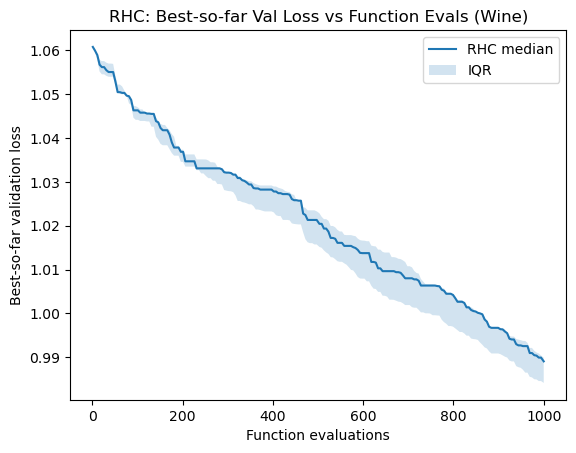

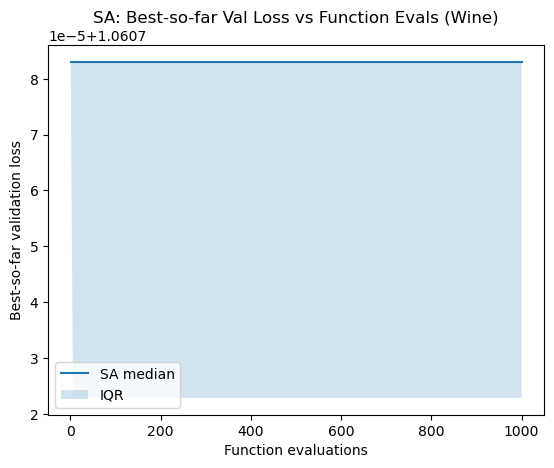

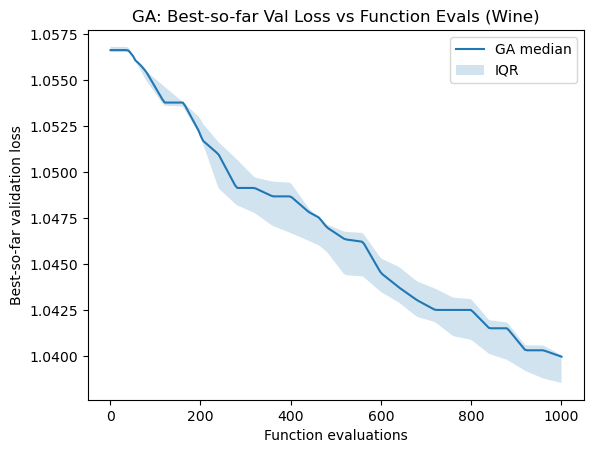

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def plot_median_iqr(runs, method, budget):
    """
    Plot median and IQR of best-so-far validation loss versus function evaluations for a given RO method
    
    Input:
        runs (list[dict]): list of run dictionaries returned by run_ro_method
        method (str): method name to filter
        budget (int): maximum number of function evaluations

    Return: None
    """
    method_runs = [r for r in runs if r["method"] == method]
    grid = np.linspace(1, budget, 200).astype(int)

    Ys = []
    for r in method_runs:
        h = r["hist"].drop_duplicates("fevals").sort_values("fevals")
        y_interp = np.interp(grid, h["fevals"].values, h["best_val_loss"].values)
        Ys.append(y_interp)

    Ys = np.vstack(Ys)
    med = np.median(Ys, axis=0)
    q1 = np.quantile(Ys, 0.25, axis=0)
    q3 = np.quantile(Ys, 0.75, axis=0)

    plt.figure()
    plt.plot(grid, med, label=f"{method} median")
    plt.fill_between(grid, q1, q3, alpha=0.2, label="IQR")
    plt.xlabel("Function evaluations")
    plt.ylabel("Best-so-far validation loss")
    plt.title(f"{method}: Best-so-far Val Loss vs Function Evals (Wine)")
    plt.legend()
    plt.show()

for m in ["RHC","SA","GA"]:
    plot_median_iqr(runs, m, BUDGET_FEVALS)


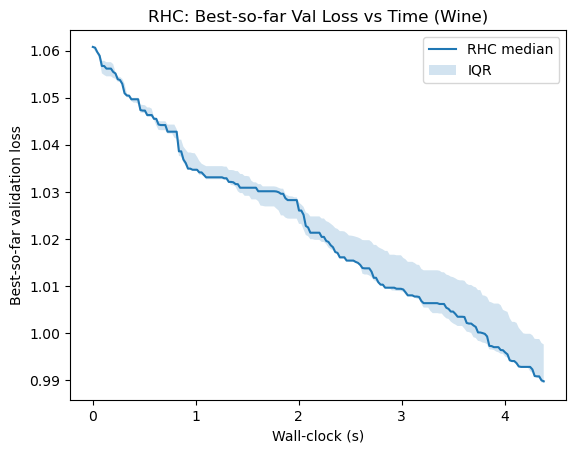

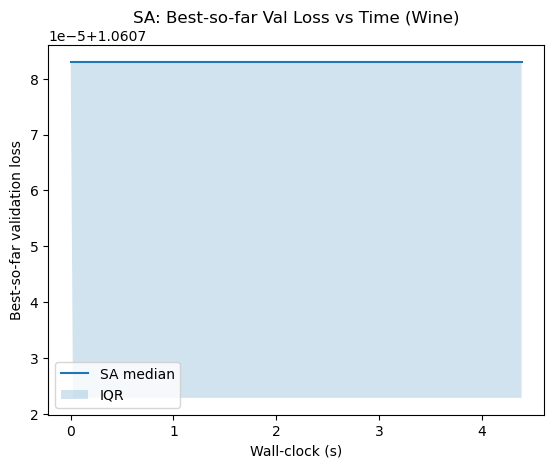

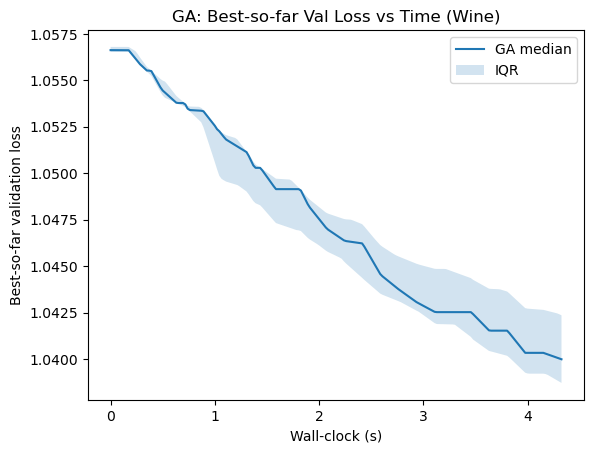

In [24]:
def plot_median_iqr_time(runs, method):
    """
    Plot median and IQR of best-so-far validation loss versus wall-clock time for a given RO method

    Input:
        runs (list[dict]): list of run dictionaries returned by run_ro_method
        method (str): method name to filter

    Return: None
    """
    method_runs = [r for r in runs if r["method"] == method]
    max_time = min(r["hist"]["time_s"].max() for r in method_runs)
    grid = np.linspace(0, max_time, 200)

    Ys = []
    for r in method_runs:
        h = r["hist"].drop_duplicates("time_s").sort_values("time_s")
        y_interp = np.interp(grid, h["time_s"].values, h["best_val_loss"].values)
        Ys.append(y_interp)

    Ys = np.vstack(Ys)
    med = np.median(Ys, axis=0)
    q1 = np.quantile(Ys, 0.25, axis=0)
    q3 = np.quantile(Ys, 0.75, axis=0)

    plt.figure()
    plt.plot(grid, med, label=f"{method} median")
    plt.fill_between(grid, q1, q3, alpha=0.2, label="IQR")
    plt.xlabel("Wall-clock (s)")
    plt.ylabel("Best-so-far validation loss")
    plt.title(f"{method}: Best-so-far Val Loss vs Time (Wine)")
    plt.legend()
    plt.show()

for m in ["RHC","SA","GA"]:
    plot_median_iqr_time(runs, m)


In [25]:
model.load_state_dict(baseline_state)
baseline_test_f1 = eval_f1(model, test_loader)
print("Baseline Test Macro-F1:", baseline_test_f1)

res_test_base = evaluate_multiclass(model, test_loader, device=device, average="macro")
y_true_test = y_test_nn.numpy() if hasattr(y_test_nn, "numpy") else y_test_nn
print("\n[TEST] Classification report:\n", classification_report(y_true_test, res_test_base["y_pred"]))


final_results = []

for method in ["RHC", "SA", "GA"]:
    method_runs = [r for r in runs if r["method"] == method]
    best_run = min(method_runs, key=lambda x: x["best_val_loss"])
    seed = best_run["seed"]

    model.load_state_dict(baseline_state)
    model.unfreeze_last_k(k=chosen_k)
    assign_flattened_trainable(model, best_vectors[(method, seed)])

    test_f1 = eval_f1(model, test_loader)
    final_results.append({
        "method": method,
        "best_seed": seed,
        "best_val_loss": best_run["best_val_loss"],
        "test_macro_f1": test_f1
    })

pd.DataFrame(final_results).sort_values("best_val_loss")


Baseline Test Macro-F1: 0.3022376892258609

[TEST] Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.00      0.00      0.00        33
           2       0.54      0.57      0.55       293
           3       0.52      0.68      0.59       450
           4       0.60      0.42      0.49       312
           5       0.53      0.56      0.55       163
           6       0.60      0.15      0.24        41
           7       0.00      0.00      0.00         4

    accuracy                           0.54      1300
   macro avg       0.35      0.30      0.30      1300
weighted avg       0.53      0.54      0.52      1300



/Users/juancarloshenriquez/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/juancarloshenriquez/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/juancarloshenriquez/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start,

,method,best_seed,best_val_loss,test_macro_f1
0,RHC,49,0.979233,0.302119
2,GA,35,1.037141,0.309581
1,SA,11,1.060663,0.304265
